In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
train = pd.read_csv("../data/train-house.csv")
test  = pd.read_csv("../data/test-house.csv")

In [9]:
train.shape

(1460, 81)

In [10]:
test.shape

(1459, 80)

In [12]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
null_pct = (train.isnull().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

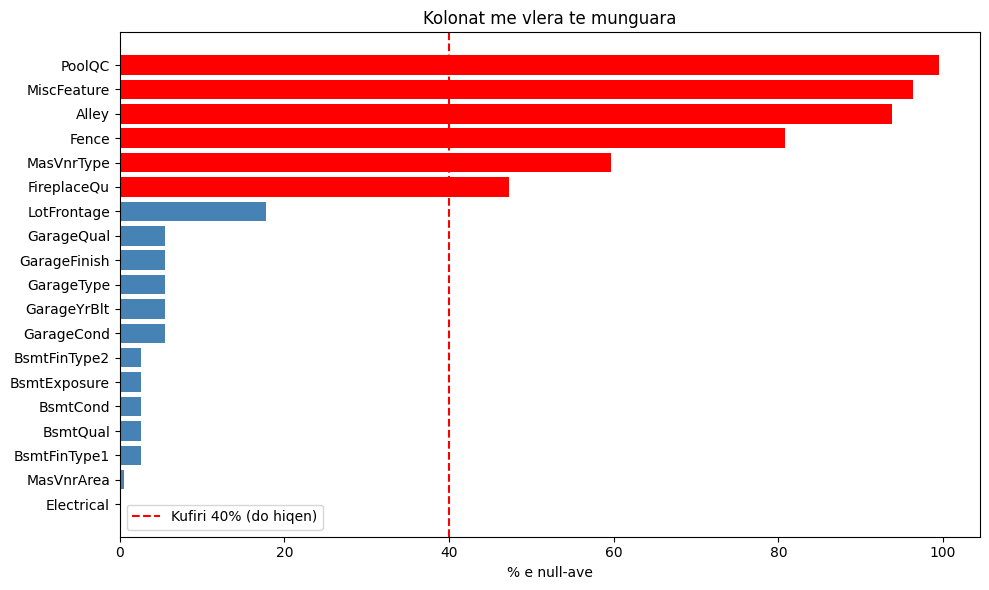

In [14]:
plt.figure(figsize=(10, 6))

colors = ["red" if v > 40 else "steelblue" for v in null_pct.values]

plt.barh(null_pct.index, null_pct.values, color=colors)
plt.axvline(x=40, color="red", linestyle="--", label="Kufiri 40% (do hiqen)")
plt.xlabel("% e null-ave")
plt.title("Kolonat me vlera te munguara")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

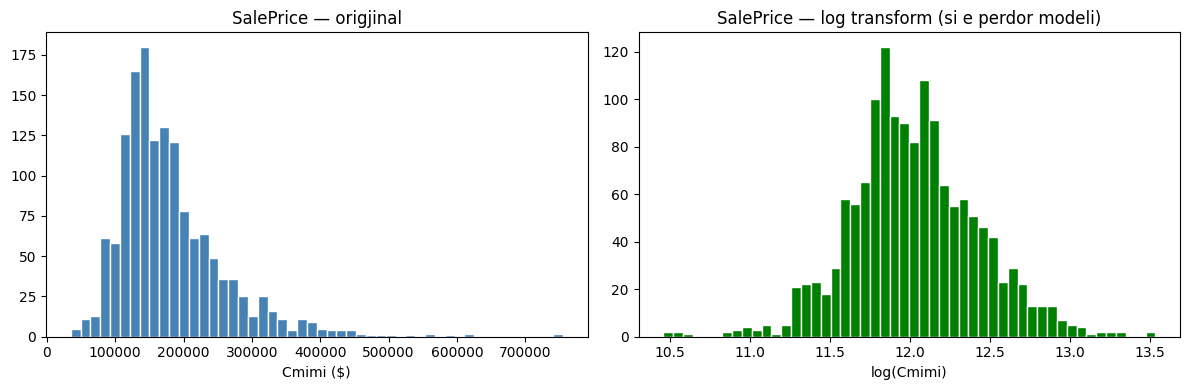

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["SalePrice"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("SalePrice — origjinal")
axes[0].set_xlabel("Cmimi ($)")

axes[1].hist(np.log1p(train["SalePrice"]), bins=50, color="green", edgecolor="white")
axes[1].set_title("SalePrice — log transform (si e perdor modeli)")
axes[1].set_xlabel("log(Cmimi)")

plt.tight_layout()
plt.show()

In [16]:
print(f"Mesatare: ${train['SalePrice'].mean():,.0f}")
print(f"Mediana: ${train['SalePrice'].median():,.0f}")
print(f"Min: ${train['SalePrice'].min():,.0f}")
print(f"Max: ${train['SalePrice'].max():,.0f}")

Mesatare: $180,921
Mediana: $163,000
Min: $34,900
Max: $755,000


In [17]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

In [18]:
corr = train[num_cols].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

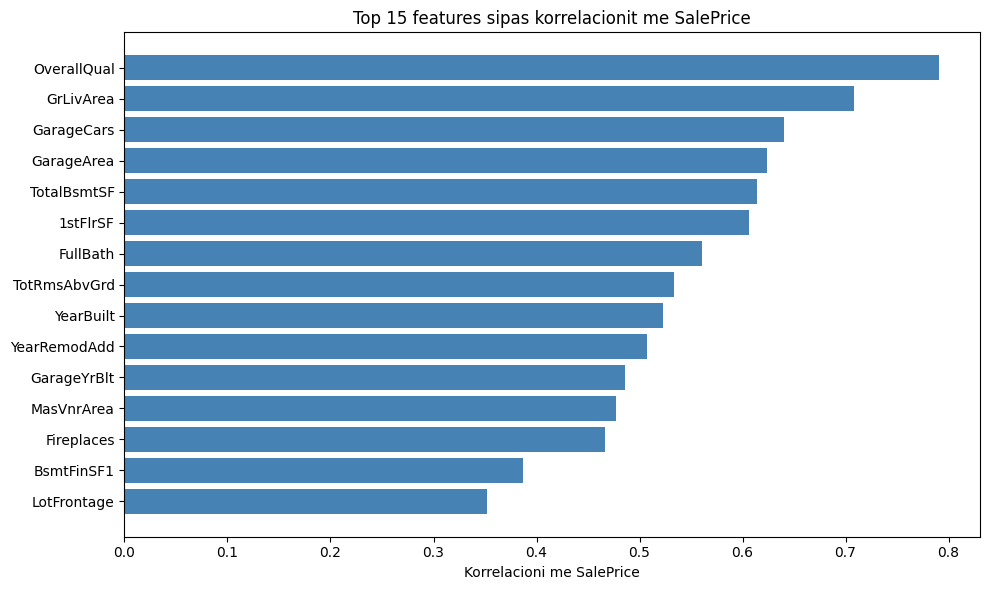

In [19]:
plt.figure(figsize=(10, 6))

colors = ["red" if v < 0 else "steelblue" for v in corr.head(15).values]

plt.barh(
    corr.head(15).index[::-1],
    corr.head(15).values[::-1],
    color=colors[::-1]
)

plt.xlabel("Korrelacioni me SalePrice")
plt.title("Top 15 features sipas korrelacionit me SalePrice")
plt.tight_layout()
plt.show()

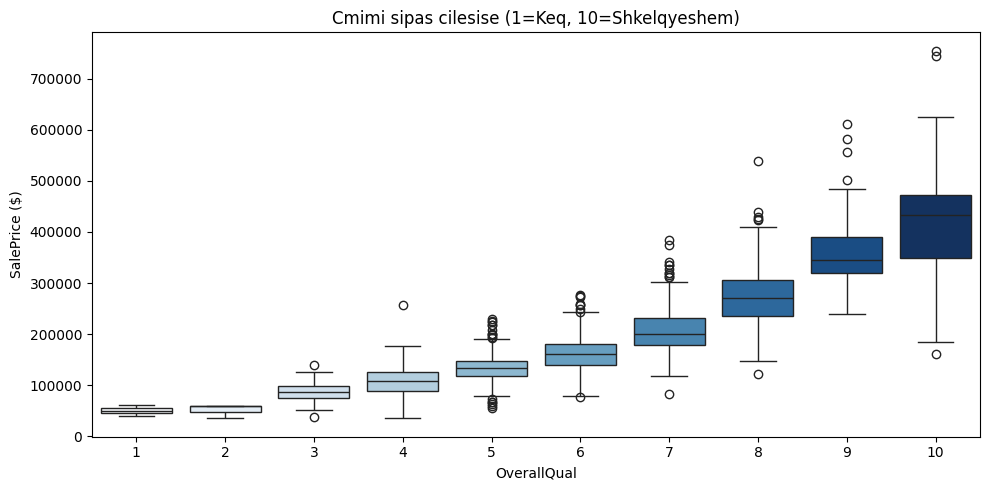

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x="OverallQual", y="SalePrice", hue="OverallQual", palette="Blues", legend=False)
plt.title("Cmimi sipas cilesise (1=Keq, 10=Shkelqyeshem)")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice ($)")
plt.tight_layout()
plt.show()

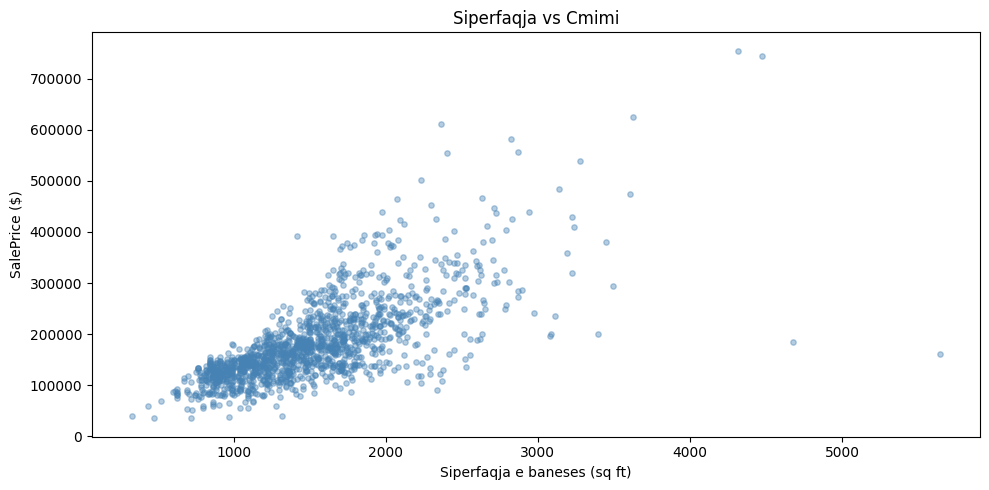

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.4, color="steelblue", s=15)
plt.xlabel("Siperfaqja e baneses (sq ft)")
plt.ylabel("SalePrice ($)")
plt.title("Siperfaqja vs Cmimi")
plt.tight_layout()
plt.show()

In [25]:
medians = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False)

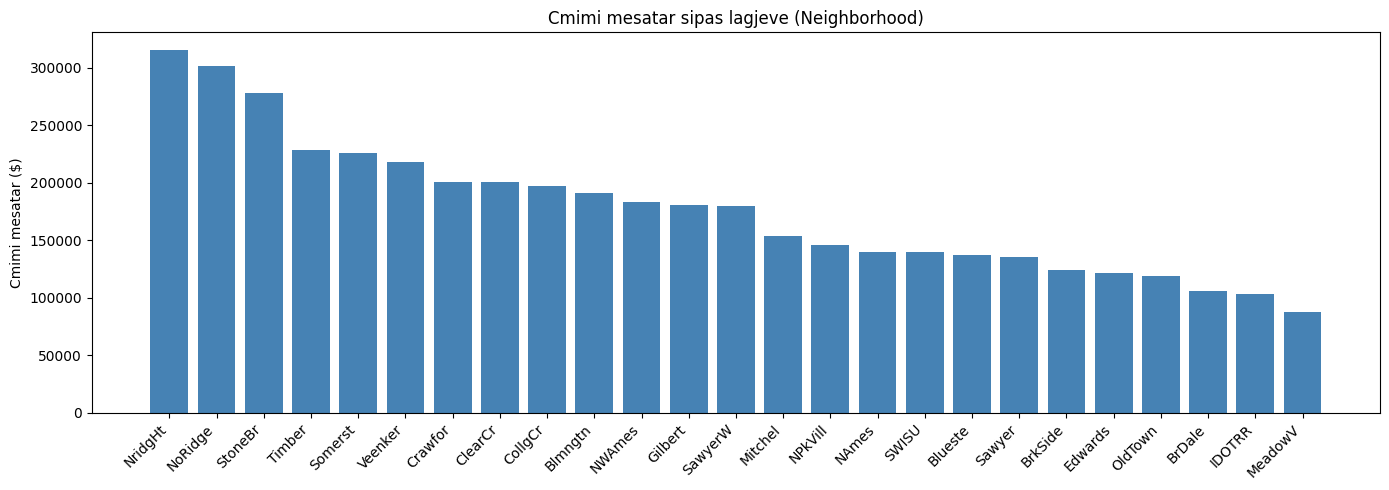

In [26]:
plt.figure(figsize=(14, 5))

plt.bar(medians.index, medians.values, color="steelblue")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cmimi mesatar ($)")
plt.title("Cmimi mesatar sipas lagjeve (Neighborhood)")
plt.tight_layout()
plt.show()